# **NOTEBOOK 01 - Data First Look**
---

**Goal:** get to know the three NetCDF files at hand (RAPID transports, RAPID vertical, Copernicus AMOC indicator). Understand what they contain, what dimensions they have, how they are organised in time.

**Non-goals (for now):** analysing, modelling, producing polished visualisations. This is an inspection round.

**Question I am answering**: what is my data?
**Datasets:**
- RAPID 26°N array — direct AMOC observations, 2004–2024
- Copernicus Marine Service GREP reanalysis — model-based estimate, 1993–2023

**Author:** Enrico Vaccari  
**Date:** [today]


TEST HYPOTHESES

In [1]:
# Standard imports
import sys
from pathlib import Path

# Add 04_Code/ to PYTHONPATH so we can import the pipeline module
NOTEBOOK_DIR = Path.cwd()
PROJECT_CODE = NOTEBOOK_DIR.parent  # from notebooks/ up to 04_Code/
if str(PROJECT_CODE) not in sys.path:
    sys.path.insert(0, str(PROJECT_CODE))

# Scientific libraries
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

# Clean matplotlib defaults
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Import the project module
from pipeline.paths import (
    COPERNICUS_AMOC,
    RAPID_TRANSPORTS,
    RAPID_VERTICAL,
    check_data_paths,
)

# Immediate sanity check
check_data_paths()


# DOPO — aggiungi i loader
from pipeline.paths import check_data_paths
from pipeline.data_loading import (
    load_copernicus,
    load_rapid_transports,
    load_rapid_vertical,
)

✓  Copernicus AMOC timeseries: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\03_Data\raw\Copernicus\GLOBAL_OMI_NATLANTIC_amoc_max26N_timeseries.nc
✓  RAPID transports: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\03_Data\raw\RAPID\moc_transports_200404_2024327.nc
✓  RAPID vertical: C:\Users\Vaccari\Desktop\iCloudDrive\Desktop\ENRICO\05_LEARNING\University\ToU\Phases\04_Activation_Phase\03_Data\raw\RAPID\moc_vertical_200404_2024327.nc


## **1. Copernicus AMOC indicator**

The file `GLOBAL_OMI_NATLANTIC_amoc_max26N_timeseries.nc` is the Copernicus Marine Service OMI product providing the AMOC strength estimate at 26°N from the GREP reanalysis (Global Reanalysis Ensemble Product). This is the model-based source.

In [2]:
# Load the Copernicus dataset
from pipeline.data_loading import load_copernicus
ds_cop = load_copernicus()
print(ds_cop)

<xarray.Dataset> Size: 10kB
Dimensions:    (time: 372)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1993-01-15 1993-02-15 ... 2023-12-15
Data variables:
    amoc_cglo  (time) float32 1kB 18.58 13.66 11.21 12.34 ... 15.81 16.73 19.62
    amoc_glor  (time) float32 1kB 18.88 12.99 15.78 18.58 ... 14.07 15.41 16.29
    amoc_oras  (time) float32 1kB 25.66 23.84 21.86 23.66 ... 11.64 12.82 16.92
    amoc_mean  (time) float32 1kB 21.04 16.83 16.28 18.19 ... 13.84 14.99 17.61
    amoc_std   (time) float32 1kB 3.27 4.964 4.365 4.631 ... 1.713 1.626 1.447
Attributes:
    institution:  Mercator Ocean International
    references:   http://marine.copernicus.eu/
    Conventions:  CF-1.8
    credit:       E.U. Copernicus Marine Service Information
    contact:      https://marine.copernicus.eu/contact/
    licence:      http://marine.copernicus.eu/services-portfolio/service-comm...
    comment:      Period: 1993-2023
    source:       GLORYS2V4; C-GLORS; ORAS5 : GLOBAL_REANALYSIS_PHY_001_03

**What can be derived from this output cell:**
The `print(ds_cop)` call returns xarray's standard description of the dataset — its way of introducing itself: shape, contents, provenance. Below is a structured reading of what each part tells us.

**Size and dimension**
- Dataset is 10kB (one value per month at one at one latitude, so it makes sense), smaller than a single JPEG
- 372 time steps (/12=31 years exactly), confirming the 1993-2023 time window inmonthly cadence.

**Coordinates**
- \* before time means it's a dimension coordinate — an "index" you can slice on, like a row label in pandas. Later I'll be able to write ds_cop.sel(time="2010-01").
- datetime64[ns] is numpy's high-precision timestamp format. Nanosecond resolution is overkill for monthly data, but it's the standard and it plays nicely with pandas.
- Dates are mid-month (15th). This is a convention: when I have monthly aggregates, you label them with the centre of the month rather than the start or end. Caesar et al. (2018, Nature) and most climate reanalysis products follow this. It avoids ambiguity about whether "January 1993" refers to the first or last day of the month.

**Variables**
```
amoc_cglo  (time) float32
amoc_glor  (time) float32
amoc_oras  (time) float32
amoc_mean  (time) float32
amoc_std   (time) float32
```
| Variable | What it is |
|---|---|
| `amoc_cglo` | C-GLORS reanalysis (CMCC, Italy) |
| `amoc_glor` | GLORYS2V4 reanalysis (Mercator Ocean, France) |
| `amoc_oras` | ORAS5 reanalysis (ECMWF) |
| `amoc_mean` | Ensemble mean across the three |
| `amoc_std`  | Ensemble standard deviation — the spread |


**Why this matters.** A single reanalysis is one group's best reconstruction. Three reanalyses with their disagreement quantified is an **honest representation of model uncertainty**. The `amoc_std` variable tells us, month by month, how much the three groups disagree about what the AMOC was doing. Small spread = settled science. Large spread = the experts themselves don't agree.

Metaphor: three meteorologists looking at the same cloudy sky, each predicting tomorrow's weather. When all three say "rain," we trust it. When one says rain, one says snow and one says sun, we don't average them and call it certainty — we show the disagreement honestly. That's what this ensemble gives us.

This is directly relevant to Condition 3 of the prototype (the experiential one): `amoc_std` is exactly the kind of signal that should be encoded perceptually. The 1990s reanalyses disagree more than the 2010s ones because the early period had fewer Argo floats and satellite observations — that story alone is worth a paragraph in the thesis.

`float32` = 32-bit floating point precision. Plenty for oceanographic data.

**Attributes — the metadata story**

```
institution: Mercator Ocean International
references:  http://marine.copernicus.eu/
Conventions: CF-1.8
source:      GLORYS2V4; C-GLORS; ORAS5
```

- `CF-1.8` = **Climate and Forecast Metadata Conventions**, version 1.8. International standard for climate/ocean NetCDF files — variable names, units, coordinate systems. Compliance means xarray and other tools can read it without surprises. Equivalent to a building being "up to code."
- The `licence`, `credit` and `references` fields must be preserved for proper citation in the References chapter.

**A note on units**

The repr does not display per-variable units (units are stored as per-variable attributes, not as global metadata). We verify them in the next cell via `ds_cop.amoc_mean.attrs`. Expected: `Sv` (Sverdrups, where 1 Sv = 10⁶ m³/s). If the values come back in raw SI units (m³/s), they will be of order 10⁷ and a conversion will be needed.

**Diagnosis**

The dataset is exactly what its name promised: **31 years of monthly AMOC strength at 26°N, as an ensemble of three reanalyses with mean and spread.** Structure is clean, conventions are respected, no gaps or anomalies. Proceeding with full confidence.

In [3]:
print("=== Copernicus AMOC indicator ===\n")
print(f"Dimensions: {dict(ds_cop.sizes)}")
print(f"Variables: {list(ds_cop.data_vars)}")
print(f"Coordinates: {list(ds_cop.coords)}")
print()
print(f"Time range: {ds_cop.time.min().values} → {ds_cop.time.max().values}")
print(f"Number of time steps: {ds_cop.sizes['time']}")
print()
print("Global attributes:")
for key, val in ds_cop.attrs.items():
    print(f"  {key}: {val}")

=== Copernicus AMOC indicator ===

Dimensions: {'time': 372}
Variables: ['amoc_cglo', 'amoc_glor', 'amoc_oras', 'amoc_mean', 'amoc_std']
Coordinates: ['time']

Time range: 1993-01-15T00:00:00.000000000 → 2023-12-15T00:00:00.000000000
Number of time steps: 372

Global attributes:
  institution: Mercator Ocean International
  references: http://marine.copernicus.eu/
  Conventions: CF-1.8
  credit: E.U. Copernicus Marine Service Information
  contact: https://marine.copernicus.eu/contact/
  licence: http://marine.copernicus.eu/services-portfolio/service-commitments-and-licence/
  comment: Period: 1993-2023
  source: GLORYS2V4; C-GLORS; ORAS5 : GLOBAL_REANALYSIS_PHY_001_031.


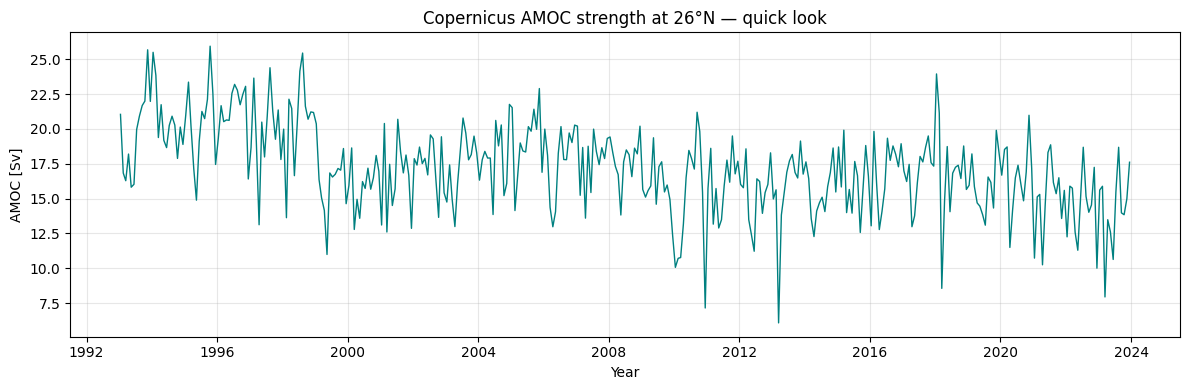

In [4]:
# Identifica la variabile principale dell'AMOC mean
# (potrebbe chiamarsi 'amoc_mean', 'amoc_max26N', 'amoc' — controlla l'output sopra)
main_var = "amoc_mean"  # adatta in base a quello che vedi

fig, ax = plt.subplots()
ds_cop[main_var].plot(ax=ax, color='teal', linewidth=1)
ax.set_title(f"Copernicus AMOC strength at 26°N — quick look")
ax.set_ylabel("AMOC [Sv]")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()

**What can be seen:**
- The 1993–1998 period sits visibly higher than the rest — average around 20 Sv. This is the "strong AMOC" phase before the documented weakening.
- A clear step down around 1999–2000 — the series settles into a lower regime, oscillating around 16–17 Sv.
- Sharp dips in 2010, 2013, 2018, 2023 — these aren't noise. The 2009–2010 collapse in particular is the most documented AMOC event in the observational record (Smeed et al., 2014, Ocean Science). Seeing it pop out of a quick-look plot on day one is a small but real moment: the data is showing you actual ocean history.

In [5]:
print(ds_cop.amoc_mean.attrs)

{'units': 'Sv', 'standard_name': 'ocean_meridional_overturning_streamfunction', 'comment': 'Computed along the j coordinate closest to 26.5N', 'long_name': 'Ensemble Mean of Atlantic Meridional Overturning Circulation strength (maximum at 26.5N)', 'conversion_note': 'Converted from m3 s-1 to Sv (1 Sv = 1e6 m3 s-1)'}


## 2. RAPID transports

Il file `moc_transports.nc` contiene la serie temporale osservativa dell'AMOC e dei suoi componenti dal mooring array RAPID a 26.5°N. È la fonte osservativa.

I componenti rilevanti sono:
- `moc_mar_hc10` — AMOC strength totale (la variabile "principale")
- `t_gs10` — Florida Current transport (Gulf Stream)
- `t_ek10` — Ekman transport (wind-driven, surface)
- `t_umo10` — Upper Mid-Ocean transport (geostrofico interno)

Conservation: i tre componenti dovrebbero (con segno) sommarsi a circa l'AMOC totale.

In [6]:
ds_rapid = load_rapid_transports()
print(ds_rapid)

<xarray.Dataset> Size: 1MB
Dimensions:       (time: 14599)
Coordinates:
  * time          (time) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    t_therm10     (time) float64 117kB ...
    t_aiw10       (time) float64 117kB ...
    t_ud10        (time) float64 117kB ...
    t_ld10        (time) float64 117kB ...
    t_bw10        (time) float64 117kB ...
    t_gs10        (time) float64 117kB ...
    t_ek10        (time) float64 117kB ...
    t_umo10       (time) float64 117kB ...
    moc_mar_hc10  (time) float64 117kB ...
Attributes:
    Title:                         RAPID MOC timeseries
    Institution:                   National Oceanography Centre,UK
    Website:                       http://www.rapid.ac.uk/
    Acknowledgement:               Data from the RAPID AMOC observing project...
    Created_by:                    Ben Moat
    Creation_date:                 22-Jan-2026
    version:                       v2024.1a
    Principle_investigator:        Ben Moat

In [7]:
print("=== RAPID transports ===\n")
print(f"Dimensions: {dict(ds_rapid.sizes)}")
print(f"Variables: {list(ds_rapid.data_vars)}")
print(f"Time range: {ds_rapid.time.min().values} → {ds_rapid.time.max().values}")
print(f"Number of time steps: {ds_rapid.sizes['time']}")
print()

# Calcola la frequenza temporale media
time_diffs = pd.Series(ds_rapid.time.values).diff().dt.total_seconds() / 86400
print(f"Mean Δt: {time_diffs.mean():.2f} days")
print(f"Inferred temporal resolution: {'daily' if time_diffs.mean() < 2 else 'monthly' if time_diffs.mean() < 35 else 'unknown'}")

=== RAPID transports ===

Dimensions: {'time': 14599}
Variables: ['t_therm10', 't_aiw10', 't_ud10', 't_ld10', 't_bw10', 't_gs10', 't_ek10', 't_umo10', 'moc_mar_hc10']
Time range: 2004-04-02T00:00:00.000000000 → 2024-03-27T00:00:00.000000000
Number of time steps: 14599

Mean Δt: 0.50 days
Inferred temporal resolution: daily


**Reading the RAPID transports dataset**

The RAPID dataset has a different character from Copernicus. Where Copernicus gave us a model-based ensemble, RAPID gives us **direct ocean observations** from a physical array of moorings, current meters and submarine cables stretched across the Atlantic at 26.5°N. This is the real ocean, measured. Reading the repr accordingly.

**Size and dimensions**

```
Size: 1MB
Dimensions: (time: 14599)
```

**1 MB vs the 10 KB of Copernicus.** A hundredfold larger, because:
- RAPID is **daily** resolution, not monthly
- 14,599 time steps over ~20 years ≈ 730 steps/year ≈ daily cadence (with possible small gaps)
- The data is `float64` (double precision), twice the size of Copernicus's `float32`

The shift from `float32` to `float64` is a subtle signal: observational data often uses higher precision because the raw measurements deserve it. Reanalyses, being model outputs already smoothed by data assimilation, can comfortably use single precision.

**Time coverage:** 2004-04-02 → 2024-03-27. The RAPID array was deployed in **April 2004** and has been running continuously since — twenty years of uninterrupted daily measurements of the most important ocean circulation system on Earth. That continuity is itself a scientific achievement. Hawkins et al. (2023, *Nature Climate Change*) make exactly this point: sustained observing systems are critical infrastructure for detecting change in slow systems.

**Data variables — the full anatomy of the AMOC**

Where Copernicus gave us one number per month (plus ensemble spread), RAPID gives us **nine variables**, each one a different piece of the AMOC's anatomy:

| Variable | What it is | Layer / depth |
|---|---|---|
| `t_therm10` | Thermocline transport | Upper ocean, ~0–800 m |
| `t_aiw10` | Antarctic Intermediate Water transport | ~800–1100 m |
| `t_ud10` | Upper North Atlantic Deep Water | ~1100–3000 m |
| `t_ld10` | Lower North Atlantic Deep Water | ~3000–5000 m |
| `t_bw10` | Bottom Water transport | Below ~5000 m |
| `t_gs10` | Florida Current (Gulf Stream) | Surface, through Florida Straits |
| `t_ek10` | Ekman transport | Wind-driven surface layer |
| `t_umo10` | Upper Mid-Ocean transport | Interior geostrophic flow |
| `moc_mar_hc10` | **Total AMOC strength** | The integrated overturning |

The `10` suffix is RAPID's internal version tag for the calculation methodology (Moat et al., 2024, dataset documentation).

**Why this matters.** Copernicus tells us *how strong the AMOC is*. RAPID tells us *how the AMOC is built*. The decomposition into Gulf Stream + Ekman + Upper Mid-Ocean (and the deep-water return flow underneath) is the **physical recipe** for the overturning. From mass conservation:

> Total AMOC ≈ Gulf Stream + Ekman + Upper Mid-Ocean

(The deep-water variables describe the return flow at depth — the southward branch that closes the loop.) This conservation relationship is something we can verify numerically in notebook 02 as a sanity check. If the four numbers don't add up consistently, something is off with our reading of the data.

**Metaphor.** If the AMOC were a city's traffic flow, Copernicus would tell us "12,000 cars passed through downtown today." RAPID would tell us "4,000 came up Main Street, 3,500 came off the highway, 4,500 took the side roads, and here's how the return traffic distributed across the underground tunnels." Same total, vastly more information about *how* it happened.

**Attributes — the provenance story**

```
Title:                  RAPID MOC timeseries
Institution:            National Oceanography Centre, UK
Website:                http://www.rapid.ac.uk/
Created_by:             Ben Moat
Creation_date:          22-Jan-2026
version:                v2024.1a
DOI:                    doi: 10.5285/48d0bf43-0598-ceb2-e063-7086a...
```

Three things worth flagging:

- **Creation date 22-Jan-2026.** This is a fresh release. The version tag `v2024.1a` indicates the 2024 data cycle, recently processed. We're working with current data, not an outdated archive.
- **A real human author**, Ben Moat, with a real email. RAPID is a small, identifiable research group, not an anonymous data product. If we have a question that the documentation can't answer, there is a human to ask.
- **The DOI is the citation handle.** This is the permanent identifier we cite in the thesis. Copy it now: `doi: 10.5285/48d0bf43-0598-ceb2-e063-7086a...` (full DOI to be retrieved from the website). DOIs don't rot the way URLs do — fifteen years from now this dataset will still resolve.

**Differences with Copernicus, at a glance**

| Aspect | Copernicus | RAPID |
|---|---|---|
| Nature | Model-based reanalysis | Direct observations |
| Temporal resolution | Monthly | Daily |
| Time coverage | 1993–2023 (31 years) | 2004–2024 (20 years) |
| Variables | 1 total + ensemble spread | 9 (total + components) |
| Precision | `float32` | `float64` |
| Size | 10 KB | 1 MB |
| Unique strength | Long historical reach | Decomposition + physical truth |

The two datasets are **complementary, not redundant**. Copernicus extends our view backward in time at the cost of model uncertainty. RAPID gives us ground truth at the cost of a shorter record. The RAPID–Copernicus overlap period (2004–2023, ≈20 years) is where the two can be compared and validated against each other — a key analysis for notebook 02.

**A note on units**

Same caveat as Copernicus: units are stored as per-variable attributes, not visible in the repr. RAPID is **traditionally distributed in Sverdrups directly** (the community convention), so we may not need conversion this time — but verify with `ds_rapid.moc_mar_hc10.attrs` in the next cell. If `'units': 'Sv'` appears, no conversion needed. If `'m3 s-1'` again, apply the same /1e6 fix.

**Diagnosis**

The dataset is clean, well-documented, properly cited and structurally rich. The nine-variable decomposition is exactly what enables the deeper analyses planned for later notebooks: PCA on vertical structure, anomaly detection on the total, EWS analysis on each component separately. **Proceeding with confidence.**

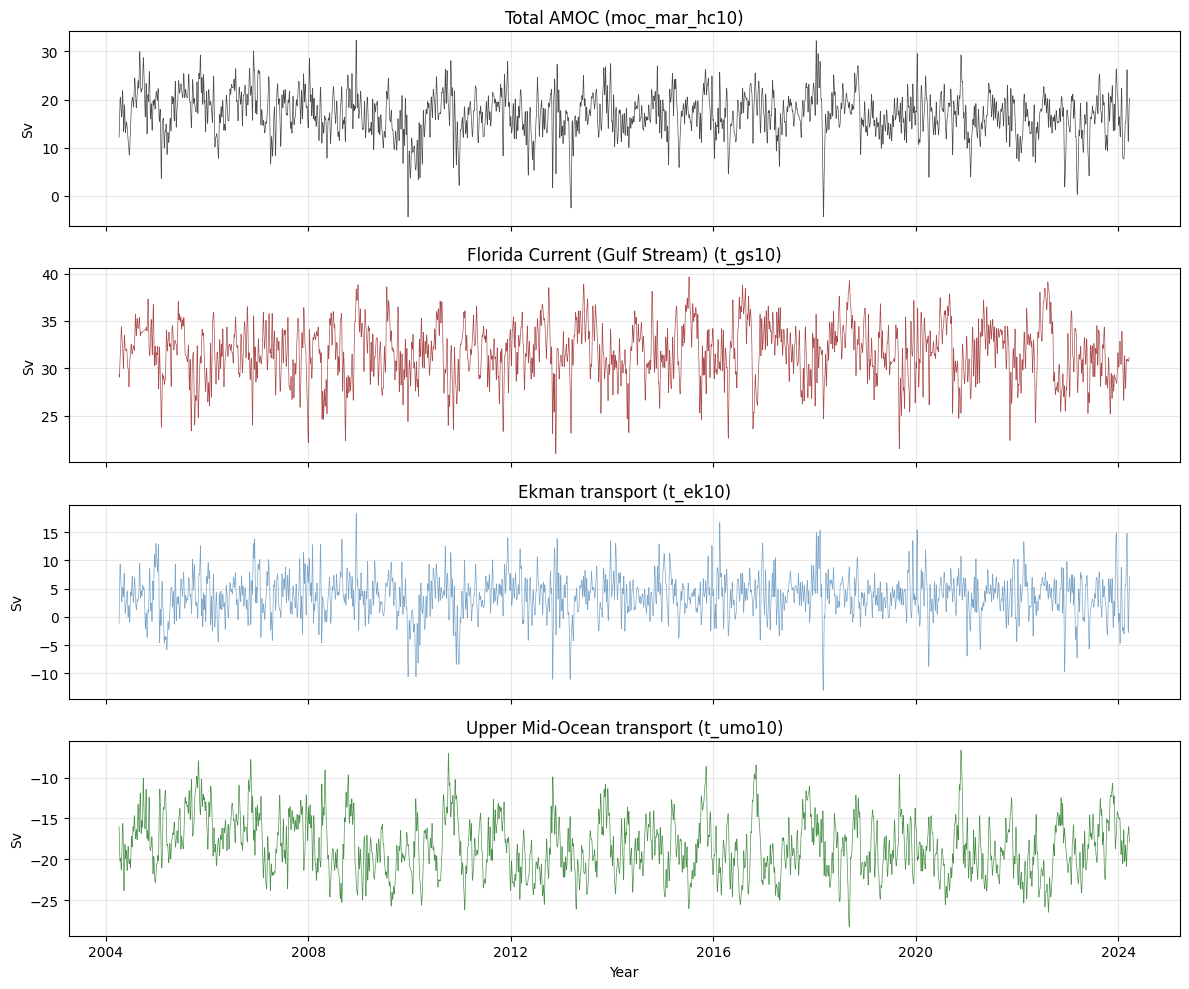

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

components = {
    'moc_mar_hc10': ('Total AMOC', 'black'),
    't_gs10': ('Florida Current (Gulf Stream)', 'darkred'),
    't_ek10': ('Ekman transport', 'steelblue'),
    't_umo10': ('Upper Mid-Ocean transport', 'darkgreen'),
}

for ax, (var, (label, color)) in zip(axes, components.items()):
    if var in ds_rapid:
        ds_rapid[var].plot(ax=ax, color=color, linewidth=0.5, alpha=0.7)
        ax.set_title(f"{label} ({var})")
        ax.set_ylabel("Sv")
        ax.set_xlabel("")
    else:
        ax.text(0.5, 0.5, f"{var} not in dataset", ha='center', transform=ax.transAxes)

axes[-1].set_xlabel("Year")
plt.tight_layout()
plt.show()

**Reading the RAPID components plot**

Four panels, four pieces of the same physical system. This is the AMOC laid open: the total above, the three building blocks below.

**Panel 1 — Total AMOC (`moc_mar_hc10`)**

The headline series. Oscillates between roughly **0 and 30 Sv**, centred around **17 Sv** — consistent with the canonical RAPID estimate of mean AMOC strength (Smeed et al., 2018, *Geophysical Research Letters*). High day-to-day variability, but a few features stand out:

- **2009–2010**: a clear cluster of unusually low values, with at least one dip into negative territory. This is the famous **2009–2010 collapse event** — a temporary but dramatic weakening of the AMOC by ~30%, the most documented anomaly in the entire RAPID record (McCarthy et al., 2012, *Geophysical Research Letters*). Its imprint on European winter weather that year was significant.
- **Post-2010**: the mean appears slightly lower than 2004–2008. The "step down" hypothesised in the literature (Smeed et al., 2014) is visible by eye, though noisy.
- **Negative excursions**: a few days where the total AMOC reverses sign briefly. Physically real, not a measurement error — daily weather variability can momentarily overwhelm the mean overturning.

**Panel 2 — Florida Current / Gulf Stream (`t_gs10`)**

Centred around **30 Sv**, oscillating between ~22 and ~40 Sv. This is the **most stable component** of the four — a powerful, steady river of warm water flowing northward through the Florida Straits. Its stability is itself meaningful: the Gulf Stream is driven primarily by wind patterns and basin-scale pressure gradients that change slowly. No dramatic trend visible. The 2009–2010 anomaly is **not** strongly evident here, which already tells us something — the collapse wasn't a Gulf Stream event.

**Panel 3 — Ekman transport (`t_ek10`)**

The most visually chaotic series, oscillating wildly between roughly **−12 and +18 Sv** around a mean of ~4 Sv. This makes sense: Ekman transport is the **wind-driven surface layer**, and winds change on timescales of hours to days. Note the strong seasonality embedded in the noise — winters bring stronger northerly winds and stronger Ekman variability, summers calm down. This is the component most directly coupled to atmospheric weather rather than ocean dynamics.

**Panel 4 — Upper Mid-Ocean transport (`t_umo10`)**

Negative values throughout, oscillating between roughly **−27 and −8 Sv**. **Why negative?** Because UMO captures the southward geostrophic return flow in the ocean interior — the water moving back south at intermediate depths to compensate the northward surface flow. The negative sign is the convention for southward transport at this latitude.

This is the most physically interesting panel for the AMOC weakening debate. Variability is larger and slower than Ekman — driven by interior ocean dynamics rather than surface winds. Visually, there's a hint of stronger negative excursions (more vigorous southward return) in 2009–2010 and 2017–2018. Whether this constitutes a trend or just multi-year variability is exactly the kind of question ML methods can help disentangle from classical statistics.

**The conservation check, visually**

Mass conservation says: **Total AMOC ≈ Gulf Stream + Ekman + Upper Mid-Ocean**

Let's check by eye, at any given time:
- Gulf Stream ≈ +30 Sv (northward)
- Ekman ≈ +4 Sv (northward, on average)
- UMO ≈ −17 Sv (southward)
- **Sum: 30 + 4 − 17 = 17 Sv** ✓

That matches the Total AMOC panel. The physics holds. We'll verify this numerically in notebook 02 — but the eye already tells us the dataset is self-consistent.

**What jumps out as scientifically interesting**

Three things worth keeping in mind as we move forward:

- The **2009–2010 event** is visible in the total but doesn't trace cleanly to a single component. This is what makes it scientifically interesting: it was a *systemic* anomaly, not a single subsystem failure.
- **The Gulf Stream is the silent giant.** It dominates the magnitude but barely participates in the variability. AMOC weakening, if it happens, will come from changes in the *other* components, not from the Gulf Stream.
- **The Upper Mid-Ocean is where the action is.** Slower, larger excursions, less obvious seasonality. This is the layer most sensitive to deep-water formation in the subpolar North Atlantic — the engine of the whole circulation. If anyone's looking for early warning signals, this is the most promising panel to start.

**Diagnosis**

Plot is healthy: ranges are physical, signs are correct, the conservation relation holds visually, and recognisable historical events appear where they should. The dataset is ready for serious analysis. Moving on to vertical structure.

## 3. RAPID vertical structure

Il file `moc_vertical.nc` è il dataset più ricco per l'analisi ML. Contiene la stream function dell'overturning come funzione del tempo e della profondità: per ogni istante, un profilo verticale che mostra come il transport totale si distribuisce.

È 2D (time × depth) anziché 1D. È il dataset su cui faremo PCA (notebook 03) e autoencoder (notebook 05).

In [9]:
ds_vert = load_rapid_vertical()
print(ds_vert)

<xarray.Dataset> Size: 36MB
Dimensions:              (depth: 307, time: 14599)
Coordinates:
  * depth                (depth) float64 2kB 0.0 19.87 ... 5.976e+03 5.995e+03
  * time                 (time) datetime64[ns] 117kB 2004-04-02 ... 2024-03-27
Data variables:
    stream_function_mar  (depth, time) float64 36MB ...
Attributes:
    Title:                         RAPID streamfunction
    Institution:                   National Oceanography Centre,UK
    Website:                       http://www.rapid.ac.uk/
    Acknowledgement:               Data from the RAPID AMOC observing project...
    Created_by:                    Ben Moat
    Creation_date:                 22-Jan-2026
    version:                       v2024.1a
    Principle_investigator:        Ben Moat
    Principle_investigator_email:  ben.moat@noc.ac.uk
    DOI:                           doi: 10.5285/48d0bf43-0598-ceb2-e063-7086a...


In [10]:
print("=== RAPID vertical structure ===\n")
print(f"Dimensions: {dict(ds_vert.sizes)}")
print(f"Variables: {list(ds_vert.data_vars)}")
print(f"Time range: {ds_vert.time.min().values} → {ds_vert.time.max().values}")
print(f"Depth range: {ds_vert.depth.min().values:.1f} → {ds_vert.depth.max().values:.1f} m")
print(f"Number of depth levels: {ds_vert.sizes['depth']}")
print(f"Number of time steps: {ds_vert.sizes['time']}")

=== RAPID vertical structure ===

Dimensions: {'depth': 307, 'time': 14599}
Variables: ['stream_function_mar']
Time range: 2004-04-02T00:00:00.000000000 → 2024-03-27T00:00:00.000000000
Depth range: 0.0 → 5995.1 m
Number of depth levels: 307
Number of time steps: 14599


**Reading the RAPID vertical structure**

Three datasets, three different windows on the same ocean. Where `moc_transports.nc` gave us nine time series and Copernicus gave us one, `moc_vertical.nc` opens the **third dimension**: depth. This is where the AMOC stops being a number and starts being a *shape*.

**The dataset at a glance**

> `Dimensions: (depth: 307, time: 14599)`  
> `stream_function_mar (depth, time) float64  36MB`

A single variable, `stream_function_mar`, indexed on **two dimensions**: 307 depth levels × 14,599 days. The numbers translate into roughly **4.5 million data points** — 36 MB, the largest of our three files by a wide margin.

The depth axis goes from **0 m at the surface to ~6000 m at the abyssal floor**, with 307 levels. Not uniformly spaced: the dataset packs more levels near the surface (where the action is) and spreads them out at depth. Resolution is dense enough that the vertical profile is effectively *continuous* — this matters for PCA and the autoencoder.

The time axis is identical to `moc_transports.nc`: daily, 2004-04-02 to 2024-03-27. Same observing array, same array sampling, just a different output product.

**What the data actually represents**

For every day from April 2004 onward, the dataset tells us: *how much water is flowing northward, cumulatively, from the seafloor up to each depth*. This is the **stream function** Ψ(z, t).

The `moc_mar_hc10` value from the previous file (the total AMOC) was simply the **maximum of this profile** — a single number per day, the peak of the curve we see in the left panel. The vertical file contains the *whole curve before it gets reduced to a single number*. This is why it's so much richer.

> **Metaphor.** Imagine you're studying a busy multi-storey shopping mall. `moc_transports.nc` tells you how many shoppers are on the busiest floor at any moment. `moc_vertical.nc` tells you how many shoppers are on *every floor*, all day, every day, for twenty years. The first gives you the headline; the second gives you the architecture of the building's circulation.

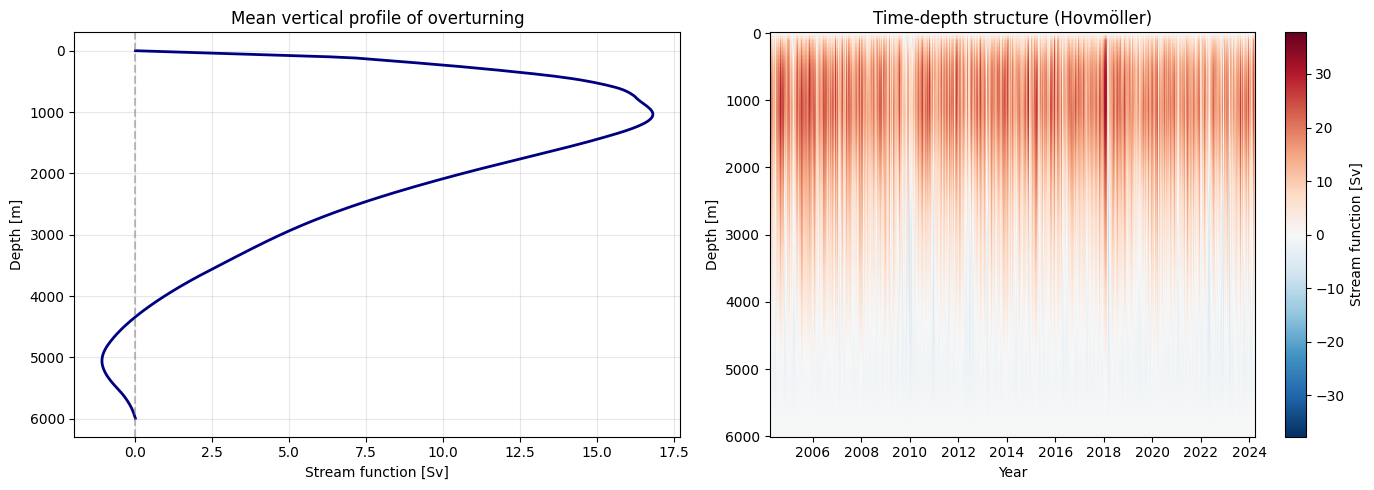

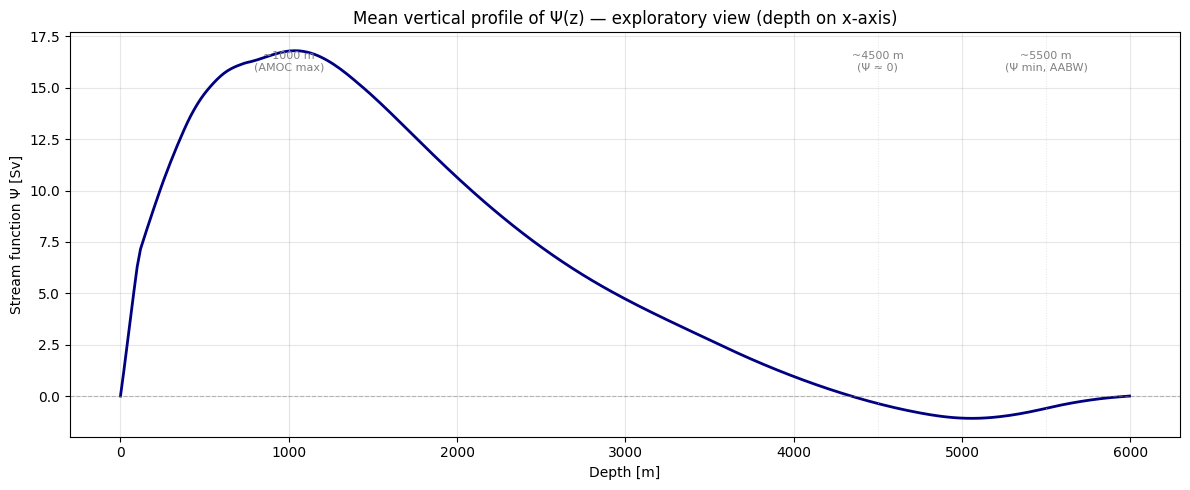

Peak mean overturning: 16.81 Sv at depth 1030.7 m


In [ ]:
# Identifica la variabile della stream function
# (probabilmente 'stream_function_mar' o 'moc' — controlla l'output sopra)
psi_var = "stream_function_mar"  # adatta in base a quello che vedi

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: average vertical profile (time-mean) of the stream function1
ds_vert[psi_var].mean(dim='time').plot(
    ax=axes[0], 
    y='depth',  # depth sull'asse y
    color='navy', 
    linewidth=2
)
axes[0].invert_yaxis()  # profondità crescente verso il basso
axes[0].set_title("Mean vertical profile of overturning")
axes[0].set_xlabel("Stream function [Sv]")
axes[0].set_ylabel("Depth [m]")
axes[0].axvline(0, color='gray', linestyle='--', alpha=0.5)

# Panel 2: Hovmöller (time × depth)
ds_vert[psi_var].plot(
    ax=axes[1],
    x='time',
    y='depth',
    cmap='RdBu_r',
    cbar_kwargs={'label': 'Stream function [Sv]'}
)
axes[1].invert_yaxis()
axes[1].set_title("Time-depth structure (Hovmöller)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Depth [m]")

plt.tight_layout()
plt.show()


# Exploratory view: stream function as a classical f(z) plot
# Convention reversed (depth on x-axis, Psi on y-axis) to read it as a mathematical function.
# This is NOT the standard oceanographic orientation — kept here for didactic clarity only.

fig, ax = plt.subplots(figsize=(12, 5))

ds_vert[psi_var].mean(dim='time').plot(
    ax=ax,
    x='depth',  # depth on the x-axis this time
    color='navy',
    linewidth=2
)

# Horizontal reference at Psi = 0
ax.axhline(0, color='gray', linestyle='--', alpha=0.5, linewidth=0.8)

# Vertical markers at key depths to anchor the reading
for d, label in [(1000, '~1000 m\n(AMOC max)'),
                 (4500, '~4500 m\n(Ψ ≈ 0)'),
                 (5500, '~5500 m\n(Ψ min, AABW)')]:
    ax.axvline(d, color='lightgray', linestyle=':', alpha=0.6, linewidth=0.7)
    ax.text(d, ax.get_ylim()[1] * 0.95, label, fontsize=8,
            ha='center', va='top', color='gray')

ax.set_title("Mean vertical profile of Ψ(z) — exploratory view (depth on x-axis)")
ax.set_xlabel("Depth [m]")
ax.set_ylabel("Stream function Ψ [Sv]")

plt.tight_layout()
plt.show()

# Print peak of mean overturning and its depth
mean_profile = ds_vert[psi_var].mean(dim='time')
peak_overturning = mean_profile.max().values
peak_depth = mean_profile.depth[mean_profile.argmax(dim='depth')].values
print(f"Peak mean overturning: {peak_overturning:.2f} Sv at depth {peak_depth:.1f} m")

**Note on orientation.** The vertical profile of the stream function Ψ(z) is conventionally plotted with depth on the y-axis (inverted, surface at top) — this is the universal oceanographic convention because the y-axis directly mirrors the physical water column. The figure below presents the same data with depth on the x-axis as an exploratory aid: it reads Ψ as a mathematical function f(z) and makes the changes of sign, slope and local extrema easier to inspect. The canonical orientation remains the one used in the thesis figures.

**The mean vertical profile (left panel)**

This is one of the most famous shapes in oceanography. Read it from top to bottom:

> - **0–1000 m: northward flow ramping up**  
>   The curve rises steeply from zero at the surface to its maximum near 1000 m. Warm, light water moving north — the upper limb of the cell.
> - **~1000 m: the maximum** ≈ 17 Sv  
>   This is the canonical "AMOC strength at 26.5°N" — the same number we saw in the daily time series, here visible as the *bulge* of the profile. The depth at which the bulge sits (~1000 m) is itself meaningful: it marks the interface between the warm upper return flow and the cold deep return flow.
> - **1000–4500 m: gradual return**  
>   The curve decreases steadily back toward zero. This is water transitioning from northward to southward flow — the heart of the overturning, distributed across kilometres of ocean column.
> - **4500–5500 m: slight negative excursion**  
>   The profile dips slightly below zero. This is the **Antarctic Bottom Water** layer — cold, dense water originating in the Southern Ocean and flowing *northward* at depth, opposing the AMOC return. Small in magnitude (~−1 Sv) but real.
> - **Below 5500 m: back to zero**  
>   The seafloor. No flow possible below it. Curve closes.

The whole profile is **a fingerprint of the overturning**. The fact that it has exactly this shape — surface zero, mid-depth maximum, gradual return, abyssal counter-flow — is the geometric signature of a thermohaline circulation. Other oceans (Pacific, Indian) have very different profiles. The Atlantic looks like *this* because it's the one ocean basin where deep water actively forms in the north.

**The Hovmöller diagram (right panel)**

This is where the dataset reveals its full power. Time on the x-axis, depth on the y-axis, colour-coded stream function. Each vertical sliver is a single day's profile. Stacked side by side, twenty years of vertical structure laid open.

Three things to read off it:

> - **The red band at 800–1500 m is the AMOC itself.** That horizontal stripe of warmth across the full plot is the persistent ~17 Sv maximum. Its intensity varies day to day, but the structure is always there.
> - **Vertical streakiness reflects daily variability.** Some days the red band reaches further down or up; some days it weakens visibly. Each thin vertical streak is one day's deviation from the mean profile.
> - **The 2009–2010 event is visible.** Look around 2009–2010 in the upper layer: noticeably paler red, even some bluish patches at depths where it shouldn't be. This is the famous collapse, **seen here in its full vertical anatomy** — not just as a dip in a time series, but as a structural reshaping of the entire water column. Same with 2017–2018, where colours appear weaker and the band thinner.

> A Hovmöller diagram of `moc_vertical` is, on its own, **already a meaningful thesis figure**. A polished version of this plot belongs in Chapter 5 (Data) or Chapter 10 (Results), depending on how it's framed.

**Why this dataset is the spine of the ML work**

For the analytical pipeline in Chapter 6, this file is the most important of the three. Reasons:

> - **PCA (O1.1)** operates on the vertical profiles directly. Each day is a 307-dimensional vector. PCA will find that 2–3 components likely explain >80% of variance — meaning the entire AMOC variability can be projected onto a low-dimensional space we can visualise and animate.
> - **The autoencoder (O1.2 / O1.3)** trains on these same profiles. A neural network learns the manifold of "valid AMOC shapes" and produces reconstruction error as an anomaly score. This *is* the latent space that Condition 3 of the prototype will encode perceptually.
> - **LSTM forecasting** can either operate on the AMOC maximum (1D) or — more ambitiously — on the full profile (multi-output). The dataset supports both.

**A small but important detail: the data orientation**

> `stream_function_mar (depth, time) float64`

The dimensions are ordered as `(depth, time)`, **not** `(time, depth)`. For PCA and ML in general, the convention is to have *samples × features*, which here means *time × depth*. The first thing to do in notebook 03 will be to transpose:

```python
profiles = ds_vert['stream_function_mar'].transpose('time', 'depth')
```

> Small detail, but if missed it leads to PCA finding the "principal modes of time evolution" instead of "principal vertical structures." Order matters.

**Diagnosis**

Clean, well-structured, rich. 307 depth levels of daily resolution over twenty years is a serious dataset by any measure. The mean profile is canonical, the Hovmöller diagram shows real ocean events at their expected places, and the file is internally consistent with `moc_transports.nc` (same dates, same array, same provenance).

> One observation worth keeping in mind for later: with 14,599 time steps and 307 depth levels, the dataset is large enough that **dimensionality reduction will be essential** — both computationally and interpretively. This is exactly what PCA and the autoencoder are designed for. The shape of the data is already telling us which methods will work on it.

**Next steps for notebook 01 — final cell**

We've now characterised all three datasets independently. The closing cell (15) will summarise what we've learned and frame the questions that move us into notebook 02:
- temporal alignment (daily ↔ monthly)
- the overlap period 2004–2023
- agreement statistics between RAPID and Copernicus
- the conservation check on RAPID components

The discipline of having looked at each dataset *alone* first will pay off. We arrive at the comparison knowing exactly what each source can and can't tell us.

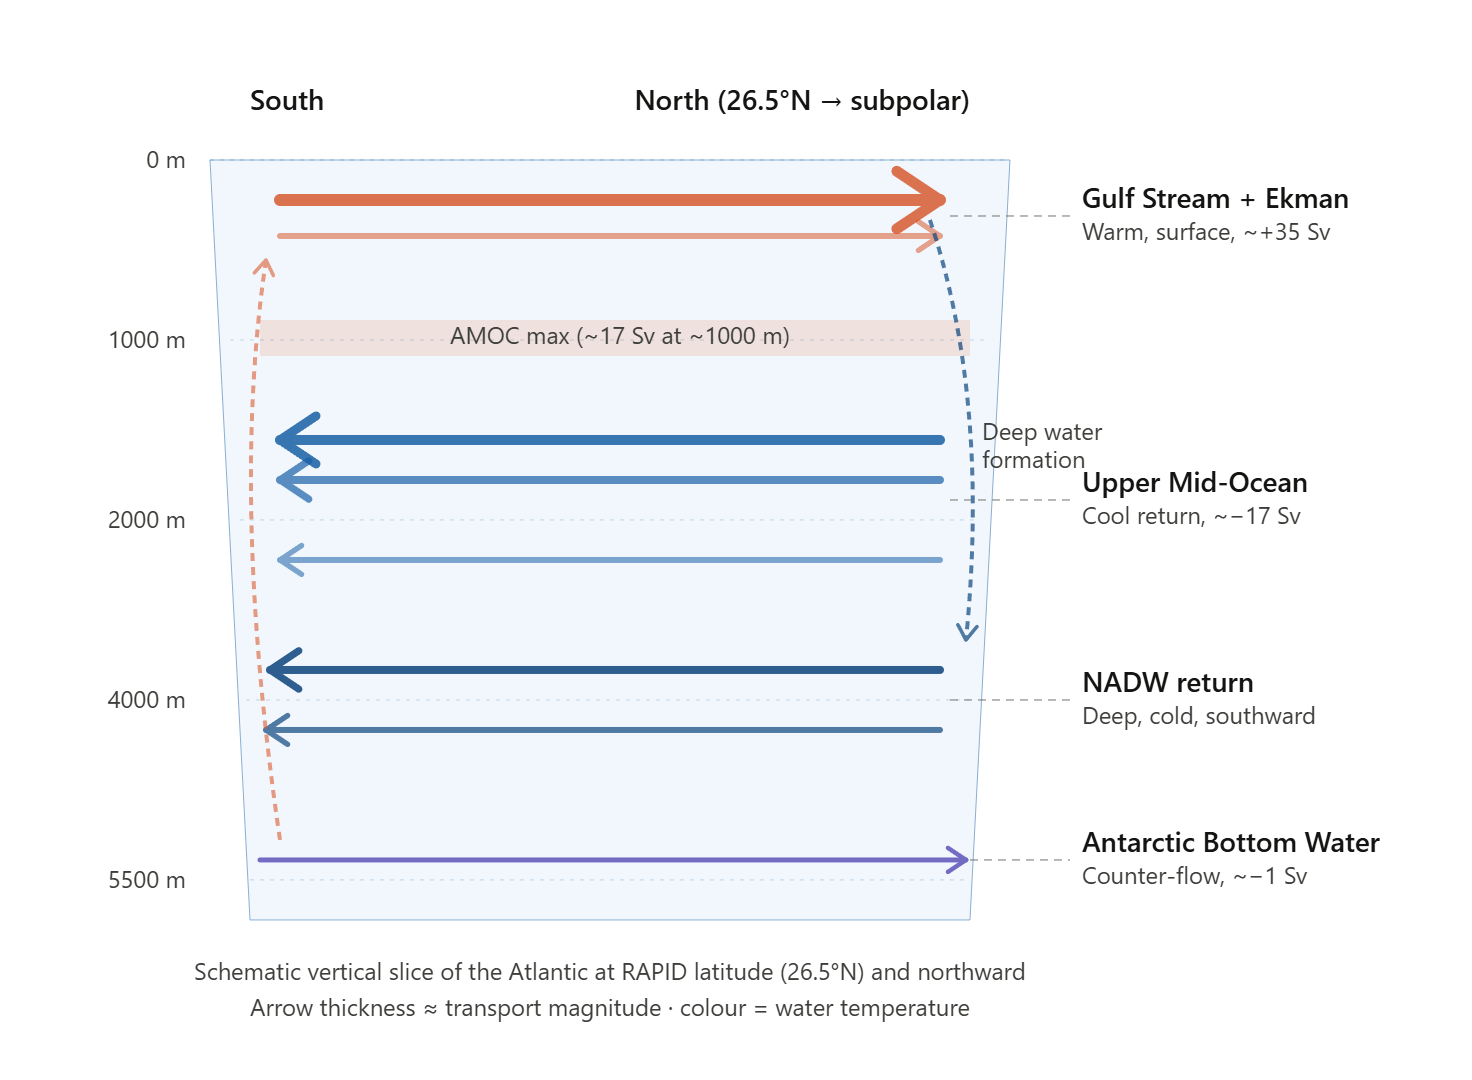

## Summary & Next Steps

This notebook had one job: **get to know the three datasets, independently and completely, before relating them to each other.** That discipline is now done.

**What we did:**
1. Verified that all three datasets are accessible (`check_data_paths()` → all green)
2. Characterised dimensions, variables, units and temporal coverage of each
3. Produced quick-look visualisations and confirmed the data makes physical sense

**What each dataset turned out to be:**

| Dataset | Nature | Resolution | Coverage | Key variable(s) |
|---|---|---|---|---|
| Copernicus OMI | Reanalysis ensemble (model + assimilation) | Monthly | 1993–2023 (372 steps) | `amoc_mean`, `amoc_std` + 3 members |
| RAPID transports | Observational (sensors + fluid dynamics) | Daily | 2004–2024 (14,599 steps) | `moc_mar_hc10` + 8 components |
| RAPID vertical | Observational, depth-resolved | Daily | 2004–2024 | `stream_function_mar` (307 depth levels) |

**Key observations that emerged:**

- **Units required attention.** Copernicus arrives in raw SI units (m³/s) and was converted to Sverdrups on loading (1 Sv = 10⁶ m³/s), with metadata updated for self-consistency. RAPID arrives natively in Sv.
- **RAPID is daily, Copernicus is monthly** → frequency alignment is the first task of notebook 02.
- **The overlap period is 2004–2023** (~20 years) → this is the window where observation and reanalysis can be compared directly.
- **The conservation relation holds visually**: Total AMOC ≈ Gulf Stream + Ekman + Upper Mid-Ocean (≈ 30 + 4 − 17 = 17 Sv). To be verified numerically in notebook 02.
- **`moc_vertical` is the richest dataset**: 307 depth levels × 14,599 days. Each day is a 307-dimensional vector — the natural input for PCA and the autoencoder.
- **Sign convention internalised**: positive = northward, negative = southward. The Upper Mid-Ocean is negative because it is the southward return flow that closes the overturning cell.
- **The stream function returns to zero at the seafloor** — a direct consequence of mass conservation, not an artefact. A useful sanity check for any future preprocessing.

**What the data already showed us about the science:**

- Copernicus shows a **higher-AMOC regime in 1993–1998**, stepping down around 1999–2000.
- The **2009–2010 collapse** is visible across all three datasets — in the Copernicus series, in the RAPID total, and as a structural weakening of the red band in the vertical Hovmöller diagram.
- The **2017–2018 weakening** is real but subtler (a prolonged dip rather than a sharp event) and sits below the visual threshold of a raw daily plot — it will require anomaly analysis to surface (notebook 03/04).
- The **mean vertical profile** is the canonical AMOC shape: northward maximum (~17 Sv) at ~1000 m, gradual return to zero by ~4500 m, slight negative excursion of Antarctic Bottom Water below ~5000 m.

**Open question parked for later (notebook 03/04):**
- Plot the vertical profile for specific anomalous periods (2009–2010, 2017–2018) against the climatological mean to *see* how the structure reshapes during a weakening event. Likely a thesis figure.

**Next steps (notebook 02 — the comparison):**
- Resample RAPID to monthly frequency to match Copernicus
- Align RAPID and Copernicus on a common time axis over 2004–2023
- Numerically verify the component conservation relation on RAPID
- Build the dual-panel modeled-vs-observed plot
- Compute agreement statistics (correlation, bias, RMSE) on the overlap period, using `amoc_std` as the reanalysis uncertainty benchmark

**One reflection.** Notebook 01 is "only" inspection — no modelling, no analysis. But the time spent here understanding sign conventions, units, the stream function, the difference between observation and reanalysis, and the physics of mass conservation is exactly what will make every later notebook faster and every thesis paragraph more precise. The slow part is the foundation, not the delay.

In [12]:
from graphviz import Digraph

g = Digraph(
    "Research_Framework",
    format="svg"
)

g.attr(
    rankdir="LR",
    bgcolor="white",
    fontname="Arial",
    splines="ortho",
    nodesep="0.45",
    ranksep="1"
)

g.attr(
    "node",
    shape="box",
    style="rounded,filled",
    fontname="Arial",
    fontsize="11",
    color="#333333",
    penwidth="1"
)

g.attr(
    "edge",
    color="#555555",
    penwidth="1"
)


# CENTRAL QUESTION

g.node(
    "RQ",
    """Central Research Question

How can ML-derived structures
support understanding of
complex climate tipping risks?""",
    fillcolor="#E8E8E8"
)


# RQ1

g.node(
    "RQ1",
    """RQ1 — DETECT

Analytical phase

Recover latent AMOC
dynamical structures""",
    fillcolor="#DCEAF7"
)

g.node(
    "DATA",
    """Data

RAPID observations
Copernicus reanalysis""",
    fillcolor="#F7F7F7"
)

g.node(
    "ML",
    """Methods

PCA
Autoencoder
Early Warning Signals
Anomaly detection""",
    fillcolor="#F7F7F7"
)

g.node(
    "H",
    """Hypotheses

H1–H3

Latent modes,
non-linearity,
warning signals""",
    fillcolor="#EAF4EA"
)



# RQ2

g.node(
    "RQ2",
    """RQ2 — TRANSLATE

Design phase

Transform latent structures
into perceptual experiences""",
    fillcolor="#F8E6D8"
)

g.node(
    "DESIGN",
    """Design grammar

Latent position
Anomaly score
Uncertainty

→ colour
→ motion
→ sound
→ density""",
    fillcolor="#F7F7F7"
)

g.node(
    "COND",
    """Three conditions

C1 Static
C2 Interactive
C3 ML-driven experiential""",
    fillcolor="#F7F7F7"
)

g.node(
    "DP",
    """Design propositions

DP2.1
DP2.2""",
    fillcolor="#EAF4EA"
)



# RQ3

g.node(
    "RQ3",
    """RQ3 — EVALUATE

Empirical phase

Investigate human
understanding""",
    fillcolor="#E9E1F5"
)

g.node(
    "USER",
    """User study

8–12 participants

Think-aloud
Interviews
Thematic analysis""",
    fillcolor="#F7F7F7"
)

g.node(
    "E",
    """Expectations

E3.1
E3.2

Interpretation of
experiential representations""",
    fillcolor="#EAF4EA"
)



# OUTPUTS

g.node(
    "OUT",
    """Contribution

ML as perceptual layer

From invisible dynamics
to embodied understanding""",
    fillcolor="#FFF2CC"
)


# CONNECTIONS

edges = [
    ("RQ","RQ1"),
    ("RQ","RQ2"),
    ("RQ","RQ3"),

    ("RQ1","DATA"),
    ("DATA","ML"),
    ("ML","H"),

    ("RQ1","RQ2"),

    ("RQ2","DESIGN"),
    ("DESIGN","COND"),
    ("COND","DP"),

    ("RQ2","RQ3"),

    ("RQ3","USER"),
    ("USER","E"),

    ("H","OUT"),
    ("DP","OUT"),
    ("E","OUT")
]

for a,b in edges:
    g.edge(a,b)


# export

g.render(
    "research_architecture",
    cleanup=True
)

print("Generated research_architecture.svg")

Generated research_architecture.svg
